## 1. Import the Tools

These packages handle data tables, plotting, model training, and evaluation. No changes are needed in this cell.

# Thinking Like a Computational Materials Scientist
## From Chemical Intuition to ML-Assisted Descriptor Discovery

**ACID Series companion notebook**

This notebook follows a simplified version of the scientific story behind a CFN study of **transition-metal release from compositionally complex battery cathode materials**.

The goal is not simply to build the Random Forest with the largest possible $R^2$. Instead, we will use machine learning as a **hypothesis-testing tool**:

1. Start with a chemically reasonable structural hypothesis.
2. Add electronic descriptors motivated by earlier work on oxidation state.
3. Ask whether a descriptor tied more directly to **metal–oxygen bonding** gives a better physical description.

> **Main idea:** Machine learning can help us identify patterns, but chemical physics is what lets us interpret them.

The dataset is embedded directly in this notebook, so no separate download or file upload is required.

In [ ]:
# Imports — do not modify
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 2. Load the CFN Dataset

The DFT-generated research dataset is embedded directly in this notebook. Each row represents one calculated metal-release environment and contains both the **DFT target energy** and descriptors derived from chemistry, structure, and electronic structure.

In [ ]:
# Load the embedded dataset — do not modify

csv_data = 'Formulation,RemovedM,dGtotal,dG1,Z,Hybrid,OS,BV_vac,Charge_vac,Mag_vac,Mag_env,Mag_inst,BV_Oxygen,Total_d_electrons,d_up_tot,d_down_tot,d_diff,t2g,eg,band_center_diff,instabilityindex,Ionicradius\nNiMnCo,Mn(1),2.852266504,7.793542563,25,1.454091585,3.5,3.921356019,11.5152,2.2992,-4.6961,-6.9953,2.238195285,5.1605,3.9233,1.2373,2.686,2.9111,2.2494,3.604292313,0.490894998,53\nNiMnCo,Co(2),2.408641042,5.549917101,27,0.824775583,2.6,3.030441627,13.9795,0.1396,-1.5905,-1.7301,2.070845833,7.3239,3.7501,3.5738,0.1763,3.9281,3.3959,3.844298721,0.490894998,54.5\nNiMnCo,Ni(3),1.122553918,4.172829977,28,0.549494545,2.4,2.755208538,15.0359,-0.8165,-3.3553,-2.5388,2.144467184,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335288,0.490894998,56\nNiMnCo,Ni(4),1.63872866,4.689004719,28,0.549494545,2.4,2.755208538,15.0359,-0.8165,-3.3553,-2.5388,2.070845833,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335288,0.490894998,56\nNiMnCo,Ni(5),0.43667129,3.486947349,28,0.397015574,2.2,2.373853816,15.0311,-1.2895,1.4369,2.7264,2.144467184,8.2444,3.5936,4.6508,1.0572,4.5311,3.7133,4.264041337,0.490894998,69\nNiMnCo,Ni(6),0.936048641,3.986324701,28,0.397015574,2.2,2.373853816,15.0311,-1.2895,1.4369,2.7264,2.238195285,8.2444,3.5936,4.6508,1.0572,4.5311,3.7133,4.264041337,0.490894998,69\nNiMnCo,Ni(7),0.717011393,3.767287452,28,0.355786063,2.1,2.707319436,15.0237,-0.8111,-1.7732,-0.9621,2.144467184,8.2906,3.5872,4.7034,1.1162,4.5702,3.7204,3.915066294,0.490894998,56\nNiMnCo,Ni(8),1.421694102,4.471970161,28,0.355786063,2.1,2.707319436,15.0237,-0.8111,-1.7732,-0.9621,2.070845833,8.2906,3.5872,4.7034,1.1162,4.5702,3.7204,3.915066294,0.490894998,56\nNiMnCo,Ni(9),1.347085284,4.397361343,28,0.610182788,2.5,2.808029329,15.0406,-0.7228,2.7716,3.4944,2.238195285,8.2477,3.7728,4.4748,0.702,4.596,3.6516,4.839279088,0.490894998,56\nMnCoNi,Co(1),1.038803034,4.180079093,27,0.75664917,2.5,2.860584567,13.9998,0.0865,11.6971,11.6106,2.262126372,7.3308,3.706,3.6247,0.0813,3.9036,3.4273,4.489548562,0.464304381,54.5\nMnCoNi,Ni(2),0.15718651,3.207462569,28,0.299739001,1.9,2.260525859,15.2029,-1.3353,11.0453,12.3806,2.133618469,8.3679,3.4824,4.8855,1.4031,4.7391,3.6289,4.328689875,0.464304381,69\nMnCoNi,Mn(3),-0.102712609,4.83856345,25,1.266639589,3.5,3.653393701,11.5247,2.0166,8.4635,6.4469,2.232756942,4.9343,4.0231,0.9112,3.1119,2.8306,2.1037,4.427591803,0.464304381,58\nMnCoNi,Mn(4),-0.102794787,4.838481272,25,1.266639589,3.5,3.653393701,11.5247,2.0166,8.4635,6.4469,2.133618469,4.9343,4.0231,0.9112,3.1119,2.8306,2.1037,4.427591803,0.464304381,58\nMnCoNi,Mn(5),-0.53467223,4.40660383,25,1.008845832,3.2,3.086261236,11.5729,3.0534,10.2703,7.2169,2.232756942,4.8933,4.1529,0.7404,3.4125,2.7812,2.1121,4.313105027,0.464304381,58\nMnCoNi,Mn(6),-0.50859412,4.432681939,25,1.008845832,3.2,3.086261236,11.5729,3.0534,10.2703,7.2169,2.262126372,4.8933,4.1529,0.7404,3.4125,2.7812,2.1121,4.313105027,0.464304381,58\nMnCoNi,Mn(8),-0.354346389,4.58692967,25,0.929263224,2.9,3.094667395,11.5984,3.0786,8.8912,5.8126,2.133618469,5.1052,4.3688,0.7365,3.6323,2.945,2.1602,4.133114162,0.464304381,58\nCoNiMn,Ni(1),1.454273422,4.504549481,28,0.323794641,2,2.349034946,15.3296,-1.2989,2.4602,3.7591,2.189134525,8.332,3.507,4.825,1.318,4.6829,3.6492,4.419823269,0.433053067,69\nCoNiMn,Mn(2),2.723200335,7.664476394,25,1.559166167,3.6,3.81621345,11.5425,2.3094,-1.2247,-3.5341,2.261749236,5.1761,3.9389,1.2372,2.7017,2.9682,2.2079,4.933677672,0.433053067,53\nCoNiMn,Co(3),1.88293442,5.024210479,27,0.744902288,2.4,2.878681282,13.9738,-0.0046,4.6852,4.6898,2.228072756,7.3893,3.6915,3.6978,0.0063,3.9307,3.4585,5.701865352,0.433053067,54.5\nCoNiMn,Co(4),2.080211328,5.221487387,27,0.744902288,2.4,2.878681282,13.9738,-0.0046,4.6852,4.6898,2.261749236,7.3893,3.6915,3.6978,0.0063,3.9307,3.4585,5.701865352,0.433053067,54.5\nCoNiMn,Co(5),2.087997188,5.229273247,27,0.729615966,2.4,2.891238823,13.9688,0.0337,-2.5697,-2.6034,2.228072756,7.3766,3.7052,3.6715,0.0337,3.8644,3.5121,5.011650674,0.433053067,54.5\nCoNiMn,Co(6),2.051853923,5.193129983,27,0.729615966,2.4,2.891238823,13.9688,0.0337,-2.5697,-2.6034,2.189134525,7.3766,3.7052,3.6715,0.0337,3.8644,3.5121,5.011650674,0.433053067,54.5\nCoNiMn,Co(7),2.039684851,5.18096091,27,0.72182209,2.4,2.873407759,13.9753,-0.006,1.0687,1.0747,2.228072756,7.3883,3.6908,3.6975,0.0067,3.8974,3.491,5.215847113,0.433053067,54.5\nCoNiMn,Co(8),2.46218858,5.603464639,27,0.72182209,2.4,2.873407759,13.9753,-0.006,1.0687,1.0747,2.261749236,7.3883,3.6908,3.6975,0.0067,3.8974,3.491,5.215847113,0.433053067,54.5\nCoNiMn,Co(9),1.974629274,5.115905333,27,0.756040375,2.4,2.872439657,13.9665,0.0447,2.0501,2.0054,2.189134525,7.3755,3.7092,3.6663,0.0429,3.8948,3.4806,4.682907768,0.433053067,54.5\nCoFeAl,Fe(1),3.381363588,6.777639647,26,0.934073834,2.7,3.943509994,12.5579,0.9231,-0.1272,-1.0503,2.422456065,6.247,3.653,2.594,1.059,3.4401,2.8068,4.039193968,0.430948962,58.5\nCoFeAl,Al(2),2.350681732,9.955957791,13,1.072081027,3,2.975172239,0.3954,0.002,0.8883,0.8863,2.226368043,0,0,0,0,0,0,3.832780344,0.430948962,53.5\nCoFeAl,Co(3),2.432895444,5.574171503,27,0.772821944,2.4,2.938265549,13.8722,0.0007,-0.0741,-0.0748,2.271890443,7.396,3.6984,3.6976,0.0008,3.916,3.48,5.561258826,0.430948962,54.5\nCoFeAl,Co(4),2.826193725,5.967469784,27,0.772821944,2.4,2.938265549,13.8722,0.0007,-0.0741,-0.0748,2.226368043,7.396,3.6984,3.6976,0.0008,3.916,3.48,5.561258826,0.430948962,54.5\nCoFeAl,Co(5),1.5497355,4.691011559,27,0.705329486,2.4,2.947897432,13.8389,-0.0465,1.8153,1.8618,2.271890443,7.3975,3.6738,3.7237,0.0499,3.8925,3.505,5.509394399,0.430948962,54.5\nCoFeAl,Co(6),1.663064366,4.804340426,27,0.705329486,2.4,2.947897432,13.8389,-0.0465,1.8153,1.8618,2.422456065,7.3975,3.6738,3.7237,0.0499,3.8925,3.505,5.509394399,0.430948962,54.5\nCoFeAl,Co(7),1.964170914,5.105446973,27,0.738456104,2.4,2.912182275,13.8576,-0.009,0.8335,0.8425,2.271890443,7.3963,3.6927,3.7036,0.0109,3.8911,3.5054,5.693759869,0.430948962,54.5\nCoFeAl,Co(8),2.241583342,5.382859401,27,0.738456104,2.4,2.912182275,13.8576,-0.009,0.8335,0.8425,2.226368043,7.3963,3.6927,3.7036,0.0109,3.8911,3.5054,5.693759869,0.430948962,54.5\nCoFeAl,Co(9),2.421799725,5.563075784,27,0.744138108,2.4,2.91550906,13.8645,-0.0136,1.8044,1.818,2.422456065,7.3941,3.6892,3.7049,0.0157,3.9048,3.4893,4.419148121,0.430948962,54.5\nFeAlCo,Al(1),1.131261246,8.736537306,13,1.040718943,3,2.96886149,0.392,0.0031,4.334,4.3309,2.453250375,0,0,0,0,0,0,4.547845041,0.43958608,53.5\nFeAlCo,Co(2),1.199092171,4.34036823,27,0.775462295,2.5,2.950880634,13.9065,-0.0447,4.5186,4.5633,2.540776298,7.3906,3.698,3.6926,0.0054,3.9406,3.45,4.363119714,0.43958608,54.5\nFeAlCo,Fe(3),0.383996059,3.780272118,26,0.795549404,2.5,3.871895056,12.7297,0.8371,3.337,2.4999,2.616477267,6.3328,3.5981,2.7347,0.8634,3.463,2.8697,4.63383173,0.43958608,58.5\nFeAlCo,Fe(4),0.591275603,3.987551663,26,0.795549404,2.5,3.871895056,12.7297,0.8371,3.337,2.4999,2.540776298,6.3328,3.5981,2.7347,0.8634,3.463,2.8697,4.63383173,0.43958608,58.5\nFeAlCo,Fe(5),0.280148663,3.676424723,26,0.759540367,2.6,3.704795906,12.6408,0.7687,3.501,2.7323,2.616477267,6.2486,3.5828,2.6658,0.917,3.3303,2.9184,4.358536043,0.43958608,58.5\nFeAlCo,Fe(6),0.714046348,4.110322407,26,0.759540367,2.6,3.704795906,12.6408,0.7687,3.501,2.7323,2.453250375,6.2486,3.5828,2.6658,0.917,3.3303,2.9184,4.358536043,0.43958608,58.5\nFeAlCo,Fe(7),0.218276411,3.61455247,26,0.696098019,2.4,3.723470697,12.6863,0.8247,3.17,2.3453,2.616477267,6.4021,3.6302,2.7718,0.8584,3.4639,2.9381,4.246418083,0.43958608,58.5\nFeAlCo,Fe(8),0.82188858,4.218164639,26,0.696098019,2.4,3.723470697,12.6863,0.8247,3.17,2.3453,2.540776298,6.4021,3.6302,2.7718,0.8584,3.4639,2.9381,4.246418083,0.43958608,58.5\nFeAlCo,Fe(9),1.720931543,5.117207602,26,0.969100095,2.8,3.862438094,12.6462,1.0083,1.5226,0.5143,2.453250375,6.2068,3.7206,2.4861,1.2345,3.4224,2.7844,4.234565773,0.43958608,58.5\nAlCoFe,Fe(2),3.434880785,6.831156844,26,0.958364565,2.8,3.764182533,12.6479,0.891,-0.0197,-0.9107,2.297173664,6.2013,3.6321,2.5692,1.0629,3.3992,2.802,4.382918811,0.406683203,58.5\nAlCoFe,Al(3),2.214438081,9.81971414,13,1.130633974,3,3.005936817,0.3789,0.0014,1.7841,1.7827,2.142639884,0,0,0,0,0,0,0.936024766,0.406683203,53.5\nAlCoFe,Al(4),1.975201677,9.580477736,13,1.130633974,3,3.005936817,0.3789,0.0014,1.7841,1.7827,2.297173664,0,0,0,0,0,0,0.936024766,0.406683203,53.5\nAlCoFe,Al(5),2.46533967,10.07061573,13,1.140513952,3,2.997776914,0.3786,0,-0.0499,-0.0499,2.142639884,0,0,0,0,0,0,0.998874273,0.406683203,53.5\nAlCoFe,Al(7),2.410315098,10.01559116,13,1.134358322,3,2.989232505,0.3732,0,0.8671,0.8671,2.142639884,0,0,0,0,0,0,0.614801422,0.406683203,53.5\nAlCoFe,Al(8),2.37201601,9.97729207,13,1.134358322,3,2.989232505,0.3732,0,0.8671,0.8671,2.297173664,0,0,0,0,0,0,0.614801422,0.406683203,53.5\nAlCoFe,Al(9),2.372531326,9.977807385,13,1.093308124,3,2.967110962,0.3815,0.0021,1.73,1.7279,2.229664079,0,0,0,0,0,0,3.043314537,0.406683203,53.5\nFeMnAl,Al(2),0.667974438,8.273250497,13,1.110561335,3,2.906644483,0.4284,-0.0004,-1.1787,-1.1783,2.424490989,0,0,0,0,0,0,3.925502745,0.398441236,53.5\nFeMnAl,Fe(4),0.763044344,4.159320403,26,0.781507659,2.3,3.625843643,12.701,-0.7852,-2.7961,-2.0109,2.424490989,6.2669,2.701,3.5659,0.8649,3.4523,2.8146,4.303791655,0.398441236,58.5\nFeXX,Fe(7),-0.271871243,3.124404817,26,0,2.3,3.54598089,12.6509,-0.6913,0.0904,0.7817,2.533477957,6.3863,2.8286,3.5577,0.7291,3.3833,3.003,4.075049824,0.398441236,58.5\nFeMnAl,Fe(8),0.298932282,3.695208341,26,0.63070066,2.3,3.54598089,12.6509,-0.6913,0.0904,0.7817,2.424490989,6.3863,2.8286,3.5577,0.7291,3.3833,3.003,4.075049824,0.398441236,58.5\nFeMnAl,Fe(9),0.827464127,4.223740186,26,0.842533988,2.6,3.634068653,12.7523,-0.8509,4.2218,5.0727,2.417236395,6.2915,2.7287,3.5628,0.8341,3.4236,2.8679,4.011651893,0.398441236,58.5\nMnAlFe,Al(1),0.38734052,7.99261658,13,1.146826705,3,2.90407735,0.4107,0.0076,13.791,13.7834,2.181852642,0,0,0,0,0,0,2.851254094,0.498176576,53.5\nMnAlFe,Mn(3),-0.938320298,4.002955762,25,0.939699411,3.1,3.100216697,11.6845,3.0136,11.3901,8.3765,2.140234583,5.3521,4.4083,0.9438,3.4645,3.2158,2.1363,5.179340742,0.498176576,58\nMnAlFe,Mn(4),-1.134978078,3.806297981,25,0.939699411,3.1,3.100216697,11.6845,3.0136,11.3901,8.3765,2.249029162,5.3521,4.4083,0.9438,3.4645,3.2158,2.1363,5.179340742,0.498176576,58\nMnAlFe,Mn(5),-0.514182184,4.427093875,25,0.993875769,2.9,3.074571702,11.6726,3.1115,11.6102,8.4987,2.140234583,5.2465,4.4366,0.81,3.6266,3.1113,2.1353,5.340185384,0.498176576,58\nMnAlFe,Mn(6),-0.614514956,4.326761103,25,0.993875769,2.9,3.074571702,11.6726,3.1115,11.6102,8.4987,2.181852642,5.2465,4.4366,0.81,3.6266,3.1113,2.1353,5.340185384,0.498176576,58\nMnAlFe,Mn(7),-0.306797944,4.634478115,25,0.939776844,3.1,2.992533465,11.669,3.1478,12.1064,8.9586,2.140234583,5.2304,4.4662,0.7643,3.7019,3.0292,2.2013,5.168804752,0.498176576,58\nMnAlFe,Mn(8),-0.702002792,4.239273268,25,0.939776844,3.1,2.992533465,11.669,3.1478,12.1064,8.9586,2.249029162,5.2304,4.4662,0.7643,3.7019,3.0292,2.2013,5.168804752,0.498176576,58\nMnAlFe,Mn(9),0.173558233,5.114834292,25,1.353102221,2.9,3.562864044,11.6369,2.2858,5.8375,3.5517,2.181852642,5.9556,4.0977,1.8579,2.2398,3.4025,2.5532,5.493968538,0.498176576,53\nAlFeMn,Fe(1),1.833454612,5.229730671,26,0.664846578,1.9,3.278669855,12.8881,0.5727,2.0205,1.4478,2.274631489,6.7816,3.4668,3.3149,0.1519,3.4723,3.3094,4.840402642,0.436768961,55\nAlFeMn,Mn(2),1.57383348,6.51510954,25,1.344094389,3,3.454174314,11.5364,2.0107,0.5875,-1.4232,2.098454835,5.8098,4.0532,1.7566,2.2966,3.2694,2.5404,5.896442222,0.436768961,53\nAlFeMn,Al(3),0.936947932,8.542223991,13,1.160326433,3,2.824625711,0.3491,0.0026,4.0272,4.0246,2.029043686,0,0,0,0,0,0,1.264790846,0.436768961,53.5\nAlFeMn,Al(4),1.136129501,8.74140556,13,1.160326433,3,2.824625711,0.3491,0.0026,4.0272,4.0246,2.098454835,0,0,0,0,0,0,1.264790846,0.436768961,53.5\nAlFeMn,Al(5),0.956406053,8.561682112,13,1.153491775,3,2.803158291,0.3567,0.0001,1.1537,1.1536,2.029043686,0,0,0,0,0,0,1.217840335,0.436768961,53.5\nAlFeMn,Al(6),0.469838671,8.07511473,13,1.153491775,3,2.803158291,0.3567,0.0001,1.1537,1.1536,2.274631489,0,0,0,0,0,0,1.217840335,0.436768961,53.5\nAlFeMn,Al(7),0.958215951,8.56349201,13,1.177809629,3,2.794600338,0.3541,0.0006,2.5888,2.5882,2.029043686,0,0,0,0,0,0,1.243423045,0.436768961,53.5\nAlFeMn,Al(8),0.649032653,8.254308712,13,1.177809629,3,2.794600338,0.3541,0.0006,2.5888,2.5882,2.098454835,0,0,0,0,0,0,1.243423045,0.436768961,53.5\nAlFeMn,Al(9),0.854324065,8.459600124,13,1.120261942,3,2.853632719,0.3574,0.0045,5.1695,5.165,2.274631489,0,0,0,0,0,0,1.802226957,0.436768961,53.5\nFeTiAl,Fe(3),0.255521738,3.651797797,26,0.846246058,2.6,3.744005584,12.7649,0.8147,2.488,1.6733,2.61689178,6.2771,3.6013,2.6758,0.9255,3.3194,2.9577,4.651528683,0.402146033,58.5\nFeTiAl,Fe(4),0.860803393,4.257079453,26,0.846246058,2.6,3.744005584,12.7649,0.8147,2.488,1.6733,2.518665929,6.2771,3.6013,2.6758,0.9255,3.3194,2.9577,4.651528683,0.402146033,58.5\nFeTiAl,Fe(5),0.861036459,4.257312518,26,0.754757981,2.4,3.554297294,12.6659,0.4395,2.7754,2.3359,2.61689178,6.381,3.431,2.95,0.481,3.3934,2.9875,4.692498704,0.402146033,58.5\nFeTiAl,Fe(6),0.064933799,3.461209859,26,0.754757981,2.4,3.554297294,12.6659,0.4395,2.7754,2.3359,2.405116212,6.381,3.431,2.95,0.481,3.3934,2.9875,4.692498704,0.402146033,58.5\nFeTiAl,Fe(7),-0.240067855,3.156208204,26,0.777173757,2.4,3.580473679,12.7165,0.6228,2.4689,1.8461,2.61689178,6.3722,3.5211,2.8511,0.67,3.4609,2.9114,4.705551518,0.402146033,58.5\nFeTiAl,Fe(8),-0.266855094,3.129420965,26,0.777173757,2.4,3.580473679,12.7165,0.6228,2.4689,1.8461,2.518665929,6.3722,3.5211,2.8511,0.67,3.4609,2.9114,4.705551518,0.402146033,58.5\nFeTiAl,Fe(9),0.937653342,4.333929401,26,0.920385691,2.6,3.645571014,12.6677,0.7985,1.1752,0.3767,2.405116212,6.3351,3.6019,2.7332,0.8687,3.484,2.851,4.103755347,0.402146033,58.5\nTiAlFe,Al,0.441746101,8.047022161,13,1.095036941,3,2.971148296,0.4458,0,-0.0077,-0.0077,2.200350045,0,0,0,0,0,0,0.143250467,0.461787081,53.5\nTiAlFe,Fe,0.096685621,3.49296168,26,0.734305792,2.3,3.287168311,11.3938,-0.0008,-0.0071,-0.0063,2.390074963,6.4494,3.179,3.2704,0.0914,3.4249,3.0244,5.310468482,0.461787081,55\nAlFeTi,Fe(1),1.762926755,5.159202814,26,0.676772969,2.2,3.33261457,12.5866,0.2146,-0.0215,-0.2361,2.394482113,6.473,3.3988,3.0743,0.3245,3.3113,3.1619,4.333044295,0.384691466,55\nAlFeTi,Al(3),0.71891492,8.324190979,13,1.157737783,3,2.934145925,0.3818,0,-0.0436,-0.0436,2.108767852,0,0,0,0,0,0,2.348535682,0.384691466,53.5\nAlFeTi,Al(4),1.194227328,8.799503388,13,1.157737783,3,2.934145925,0.3818,0,-0.0436,-0.0436,2.084041856,0,0,0,0,0,0,2.348535682,0.384691466,53.5\nAlFeTi,Al(5),0.999541762,8.604817821,13,1.16994909,3,2.929900266,0.3827,0.0002,0.4292,0.429,2.108767852,0,0,0,0,0,0,0.299322111,0.384691466,53.5\nAlFeTi,Al(6),0.594082708,8.199358767,13,1.16994909,3,2.929900266,0.3827,0.0002,0.4292,0.429,2.394482113,0,0,0,0,0,0,0.299322111,0.384691466,53.5\nAlFeTi,Al(7),1.146717795,8.751993855,13,1.184613404,3,2.928021983,0.3805,0,0.215,0.215,2.108767852,0,0,0,0,0,0,1.664806281,0.384691466,53.5\nAlFeTi,Al(8),0.94041031,8.545686369,13,1.184613404,3,2.928021983,0.3805,0,0.215,0.215,2.084041856,0,0,0,0,0,0,1.664806281,0.384691466,53.5\nAlFeTi,Al(9),0.615655971,8.22093203,13,1.150365777,3,2.982349218,0.4012,0,0.3856,0.3856,2.394482113,0,0,0,0,0,0,0.491954945,0.384691466,53.5\nFeTiV,V(2),-1.913667113,7.221969024,23,1.954864497,3.8,3.543250377,8.8919,-0.4118,11.1858,11.5976,2.11907861,3.3711,1.3852,1.9859,0.6007,2.0729,1.2982,3.647644567,0.408846222,58\nFeTiV,Fe(3),0.283663831,3.679939891,26,0.536768435,2.7,2.60236201,12.6611,3.2956,9.8977,6.6021,2.153887084,6.0777,4.9167,1.161,3.7557,3.6916,2.3862,4.597361067,0.408846222,55\nFeTiV,Fe(4),0.572107692,3.968383751,26,0.536768435,2.7,2.60236201,12.6611,3.2956,9.8977,6.6021,2.11907861,6.0777,4.9167,1.161,3.7557,3.6916,2.3862,4.597361067,0.408846222,55\nFeTiV,Fe(5),0.263878834,3.660154893,26,0.602031012,2.5,2.618024839,12.6133,3.3455,10.6554,7.3099,2.153887084,6.0194,4.9327,1.0867,3.846,3.6177,2.4016,4.82037101,0.408846222,55\nFeTiV,Fe(6),0.77827327,4.174549329,26,0.602031012,2.5,2.618024839,12.6133,3.3455,10.6554,7.3099,2.224560207,6.0194,4.9327,1.0867,3.846,3.6177,2.4016,4.82037101,0.408846222,55\nFeTiV,Fe(7),0.777310803,4.173586862,26,0.579250213,2.7,2.593396145,12.7123,3.383,12.8624,9.4794,2.153887084,5.9998,4.9352,1.0646,3.8706,3.6654,2.3344,4.764561716,0.408846222,55\nFeTiV,Fe(8),0.035645085,3.431921144,26,0.579250213,2.7,2.593396145,12.7123,3.383,12.8624,9.4794,2.11907861,5.9998,4.9352,1.0646,3.8706,3.6654,2.3344,4.764561716,0.408846222,55\nFeTiV,Fe(9),0.034560167,3.430836226,26,0.891423563,2.7,3.509322905,12.716,0.6098,6.2213,5.6115,2.224560207,6.27,3.5067,2.7633,0.7434,3.4106,2.8594,4.169576828,0.408846222,58.5\nTiVFe,V,-2.470328126,6.665308011,23,1.441221641,3.3,2.858786823,8.7231,-1.1637,2.6875,3.8512,2.217333828,3.2738,0.9709,2.3029,1.332,1.9327,1.3411,4.001249055,0.465190551,64\nTiVFe,Fe,0.056040775,3.452316834,26,0.729431341,2.4,2.375304118,11.5722,2.5637,-1.7547,-4.3184,2.095323988,6.3846,3.238,3.1466,0.0914,3.3798,3.0048,4.918306939,0.465190551,61\nVFeTi,V(3),-3.951773063,5.183863074,23,1.205192291,2.8,2.967051848,9.665,-1.4508,-5.3792,-3.9284,2.176825352,3.5007,0.7562,2.7445,1.9883,1.9388,1.5619,4.558608194,0.405156583,64\nVFeTi,V(5),-3.807145377,5.32849076,23,1.308283252,3.1,3.00980754,9.6512,-1.2379,0.5807,1.8186,2.176825352,3.4431,0.9055,2.5376,1.6321,2.0065,1.4366,4.429799747,0.405156583,64\nVFeTi,V(6),-3.520696044,5.614940093,23,1.308283252,3.1,3.00980754,9.6512,-1.2379,0.5807,1.8186,2.116514924,3.4431,0.9055,2.5376,1.6321,2.0065,1.4366,4.429799747,0.405156583,64\nVFeTi,V(7),-3.031320038,6.104316099,23,1.311498406,2.9,3.016769783,9.6508,-1.2892,-2.4028,-1.1136,2.176825352,3.4364,0.8671,2.5693,1.7022,1.9956,1.4408,4.525037234,0.405156583,64\nVFeTi,V(8),-3.152438778,5.983197359,23,1.311498406,2.9,3.016769783,9.6508,-1.2892,-2.4028,-1.1136,2.167110909,3.4364,0.8671,2.5693,1.7022,1.9956,1.4408,4.525037234,0.405156583,64\nVFeTi,V(9),-3.340630617,5.79500552,23,1.294827444,3,2.992175317,9.6492,-1.3393,0.0623,1.4016,2.116514924,3.5658,0.8384,2.7274,1.889,2.0173,1.5482,3.869753158,0.405156583,64\nNiMnAl,Mn(1),3.269852317,8.211128376,25,1.50952672,3.5,3.915320455,11.4563,-2.2918,4.7416,7.0334,2.21184986,5.1679,1.2426,3.9253,2.6827,2.9194,2.2486,3.504027367,0.495149385,53\nNiMnAl,Al(2),2.444080155,10.04935621,13,1.016879413,3,2.946578317,0.4143,-0.0029,1.4841,1.487,2.096749462,0,0,0,0,0,0,5.553243297,0.495149385,53.5\nNiMnAl,Ni(3),1.191674674,4.241950733,28,0.593799838,2.5,2.763263391,15.0383,0.7775,3.5726,2.7951,2.110499025,8.2404,4.5179,3.7225,0.7954,4.7081,3.5322,4.510555117,0.495149385,56\nNiMnAl,Ni(4),1.938381506,4.988657566,28,0.593799838,2.5,2.763263391,15.0383,0.7775,3.5726,2.7951,2.096749462,8.2404,4.5179,3.7225,0.7954,4.7081,3.5322,4.510555117,0.495149385,56\nNiMnAl,Ni(5),0.435498683,3.485774742,28,0.395900544,2.2,2.412858237,15.0428,1.2618,-1.4895,-2.7513,2.110499025,8.2909,4.6849,3.606,1.0789,4.5741,3.7169,4.28235927,0.495149385,69\nNiMnAl,Ni(6),1.027765536,4.078041596,28,0.395900544,2.2,2.412858237,15.0428,1.2618,-1.4895,-2.7513,2.21184986,8.2909,4.6849,3.606,1.0789,4.5741,3.7169,4.28235927,0.495149385,69\nNiMnAl,Ni(7),0.855179637,3.905455697,28,0.366548951,2.1,2.712130447,15.038,0.8041,1.7839,0.9798,2.110499025,8.2939,4.7079,3.586,1.1219,4.575,3.7189,3.812055182,0.495149385,56\nNiMnAl,Ni(8),1.478617621,4.528893681,28,0.366548951,2.1,2.712130447,15.038,0.8041,1.7839,0.9798,2.096749462,8.2939,4.7079,3.586,1.1219,4.575,3.7189,3.812055182,0.495149385,56\nNiMnAl,Ni(9),1.763383453,4.813659512,28,0.693710694,2.6,2.790731386,15.0403,0.7084,-2.5501,-3.2585,2.21184986,8.2434,4.4471,3.7963,0.6508,4.5867,3.6567,4.689193329,0.495149385,56\nMnAlNi,Al(1),0.73526203,8.340538089,13,1.045073662,3,2.922187111,0.4101,-0.0064,-7.9049,-7.8985,2.283054158,0,0,0,0,0,0,3.476240855,0.417982742,53.5\nMnAlNi,Ni(2),0.105983642,3.156259701,28,0.514544995,2.2,2.241132423,15.0525,1.3756,-9.5671,-10.9427,2.349853373,8.3051,4.6983,3.6068,1.0915,4.6659,3.6391,5.346764306,0.417982742,69\nMnAlNi,Mn(3),-0.351049933,4.590226127,25,1.064762772,2.8,3.531384124,11.6514,-1.8221,-4.3927,-2.5706,2.446037495,5.4272,1.6335,3.7937,2.1602,2.9801,2.447,5.415675353,0.417982742,53\nMnAlNi,Mn(4),-0.962800282,3.978475778,25,1.064762772,2.8,3.531384124,11.6514,-1.8221,-4.3927,-2.5706,2.349853373,5.4272,1.6335,3.7937,2.1602,2.9801,2.447,5.415675353,0.417982742,53\nMnAlNi,Mn(5),-0.837313908,4.103962151,25,0.968172893,2.6,3.410051337,11.5439,-1.682,-7.2968,-5.6148,2.446037495,5.4498,1.7686,3.6812,1.9126,2.9999,2.45,5.290282847,0.417982742,58\nMnAlNi,Mn(6),-0.662649807,4.278626253,25,0.968172893,2.6,3.410051337,11.5439,-1.682,-7.2968,-5.6148,2.283054158,5.4498,1.7686,3.6812,1.9126,2.9999,2.45,5.290282847,0.417982742,58\nMnAlNi,Mn(7),-0.138166473,4.803109586,25,0.937331903,2.6,3.453257452,11.6409,-1.6691,-5.639,-3.9699,2.446037495,5.4114,1.6745,3.7369,2.0624,2.9734,2.4379,4.939595666,0.417982742,58\nMnAlNi,Mn(8),-0.653812362,4.287463698,25,0.937331903,2.6,3.453257452,11.6409,-1.6691,-5.639,-3.9699,2.349853373,5.4114,1.6745,3.7369,2.0624,2.9734,2.4379,4.939595666,0.417982742,58\nAlNiMn,Ni(1),2.523047468,5.573323528,28,0.287669297,2,2.163028292,15.4231,1.3088,-2.333,-3.6418,2.15063633,8.3737,4.8463,3.5274,1.3189,4.6968,3.677,3.706936719,0.417464437,69\nAlNiMn,Mn(2),3.934600329,8.875876389,25,1.734809214,3.9,3.84805483,11.4687,-2.3173,1.2885,3.6058,2.173915675,5.1759,1.2274,3.9485,2.7211,2.9821,2.1939,4.6002609,0.417464437,53\nAlNiMn,Al(3),2.254713872,9.859989931,13,1.207089237,3,2.924120617,0.3614,-0.0031,-4.6435,-4.6404,2.085419903,0,0,0,0,0,0,3.170153795,0.417464437,53.5\nAlNiMn,Al(4),2.903984791,10.50926085,13,1.207089237,3,2.924120617,0.3614,-0.0031,-4.6435,-4.6404,2.173915675,0,0,0,0,0,0,3.170153795,0.417464437,53.5\nAlNiMn,Al(5),2.660922464,10.26619852,13,1.198612534,3,2.857612571,0.3591,-0.0008,2.6064,2.6072,2.085419903,0,0,0,0,0,0,4.017945488,0.417464437,53.5\nAlNiMn,Al(6),2.420752369,10.02602843,13,1.198612534,3,2.857612571,0.3591,-0.0008,2.6064,2.6072,2.15063633,0,0,0,0,0,0,4.017945488,0.417464437,53.5\nAlNiMn,Al(7),2.735466383,10.34074244,13,1.187940428,3,2.908481165,0.3642,-0.0007,-1.0163,-1.0156,2.085419903,0,0,0,0,0,0,3.663966821,0.417464437,53.5\nAlNiMn,Al(8),2.643170634,10.24844669,13,1.187940428,3,2.908481165,0.3642,-0.0007,-1.0163,-1.0156,2.173915675,0,0,0,0,0,0,3.663966821,0.417464437,53.5\nAlNiMn,Al(9),2.399442921,10.00471898,13,1.131193713,3,2.886478955,0.3591,-0.0067,-2.0209,-2.0142,2.15063633,0,0,0,0,0,0,4.390908991,0.417464437,53.5\nNiMnFe,Mn(1),2.492842057,7.434118116,25,1.488096116,3.6,3.800910166,11.5879,2.406,4.3758,1.9698,2.205891148,5.0703,3.901,1.1693,2.7317,2.8999,2.1704,3.163293824,0.491425033,53\nNiMnFe,Fe(2),2.464489745,5.860765805,26,1.247528397,3.6,4.125326403,12.6208,-1.3876,7.5546,8.9422,2.128031072,5.7911,1.9146,3.8765,1.9619,3.2538,2.5373,3.240373185,0.491425033,58.5\nNiMnFe,Ni(3),0.926266621,3.97654268,28,0.476852318,2.4,2.566708514,15.0732,0.9803,1.503,0.5227,2.11357441,8.1734,4.5421,3.6314,0.9107,4.6756,3.4979,4.011438059,0.491425033,56\nNiMnFe,Ni(4),0.92905504,3.9793311,28,0.476852318,2.4,2.566708514,15.0732,0.9803,1.503,0.5227,2.128031072,8.1734,4.5421,3.6314,0.9107,4.6756,3.4979,4.011438059,0.491425033,56\nNiMnFe,Ni(5),0.92879177,3.979067829,28,0.436506125,2.4,2.30142597,15.0649,1.2877,8.7828,7.4951,2.11357441,8.1464,4.5598,3.5867,0.9731,4.441,3.7054,3.925385931,0.491425033,69\nNiMnFe,Ni(6),1.146568859,4.196844919,28,0.436506125,2.4,2.30142597,15.0649,1.2877,8.7828,7.4951,2.205891148,8.1464,4.5598,3.5867,0.9731,4.441,3.7054,3.925385931,0.491425033,69\nNiMnFe,Ni(7),0.482161193,3.532437253,28,0.448074574,2.3,2.547629187,15.0172,0.931,5.5544,4.6234,2.11357441,8.214,4.5993,3.6147,0.9846,4.4957,3.7184,3.992671,0.491425033,56\nNiMnFe,Ni(8),0.885150949,3.935427009,28,0.448074574,2.3,2.547629187,15.0172,0.931,5.5544,4.6234,2.128031072,8.214,4.5993,3.6147,0.9846,4.4957,3.7184,3.992671,0.491425033,56\nNiMnFe,Ni(9),0.87153702,3.921813079,28,0.435228556,2.7,2.43301714,15.1135,1.1285,4.3048,3.1763,2.205891148,7.7776,4.2959,3.4817,0.8142,4.2874,3.4901,3.19562926,0.491425033,69\nMnFeNi,Fe(1),0.782692401,4.17896846,26,0.938003796,3.3,3.753347202,12.852,-0.7784,15.974,16.7524,2.301930153,5.9511,1.3135,4.6375,3.324,3.4786,2.4724,4.678809504,0.498235616,58.5\nMnFeNi,Ni(2),-0.089104245,2.961171815,28,0.495917989,2.3,2.069727111,15.1557,1.5093,13.6757,12.1664,2.060468607,8.2347,4.6632,3.5715,1.0917,4.6459,3.5889,4.907291505,0.498235616,69\nMnFeNi,Mn(3),-0.003597071,4.937678988,25,1.051731498,2.9,3.05815397,11.7333,3.1378,15.0175,11.8797,2.115954836,5.309,3.7972,1.5118,2.2854,2.9001,2.4089,4.956930766,0.498235616,58\nMnFeNi,Mn(4),-0.271656127,4.669619933,25,1.051731498,2.9,3.05815397,11.7333,3.1378,15.0175,11.8797,2.060468607,5.309,3.7972,1.5118,2.2854,2.9001,2.4089,4.956930766,0.498235616,58\nMnFeNi,Mn(5),-0.641369406,4.299906653,25,0.924797197,2.5,3.072355231,11.6996,3.1431,10.4368,7.2937,2.115954836,5.5099,3.806,1.7039,2.1021,3.0389,2.471,4.989452918,0.498235616,58\nMnFeNi,Mn(6),-0.981357638,3.959918422,25,0.924797197,2.5,3.072355231,11.6996,3.1431,10.4368,7.2937,2.301930153,5.5099,3.806,1.7039,2.1021,3.0389,2.471,4.989452918,0.498235616,58\nMnFeNi,Mn(7),0.09157295,5.032849009,25,0.869052783,2.6,3.030050456,11.7125,3.1777,13.2927,10.115,2.115954836,5.3998,3.9458,1.454,2.4918,2.9892,2.4106,4.64829926,0.498235616,58\nMnFeNi,Mn(8),-0.271478912,4.669797147,25,0.869052783,2.6,3.030050456,11.7125,3.1777,13.2927,10.115,2.060468607,5.3998,3.9458,1.454,2.4918,2.9892,2.4106,4.64829926,0.498235616,58\nMnFeNi,Mn(9),0.374084862,5.315360921,25,1.228631317,3.2,3.712534718,11.6731,2.5004,7.7427,5.2423,2.301930153,5.1968,3.9269,1.2699,2.657,2.9507,2.2462,4.649039816,0.498235616,53\nFeNiMn,Ni(1),0.321736952,3.372013011,28,0.360055812,2.1,2.319746083,15.0396,1.2188,-8.9738,-10.1926,2.266504098,8.306,4.7768,3.5291,1.2477,4.6893,3.6167,4.307170289,0.420107922,69\nFeNiMn,Mn(2),1.442099846,6.383375906,25,1.518938985,3.5,3.81225019,11.7032,2.4183,-11.6717,-14.09,2.136691508,5.1569,3.9654,1.1914,2.774,2.9649,2.192,4.214147002,0.420107922,53\nFeNiMn,Fe(3),0.341079061,3.73735512,26,0.633228335,2.8,2.742840434,12.76,-3.4751,-6.1822,-2.7071,2.076427808,5.9668,1.0312,4.9356,3.9044,3.6366,2.3302,4.579891245,0.420107922,55\nFeNiMn,Fe(4),0.818151639,4.214427698,26,0.633228335,2.8,2.742840434,12.76,-3.4751,-6.1822,-2.7071,2.136691508,5.9668,1.0312,4.9356,3.9044,3.6366,2.3302,4.579891245,0.420107922,55\nFeNiMn,Fe(5),1.105110029,4.501386088,26,1.150622233,3.5,3.451596086,12.7048,-2.7259,-9.3304,-6.6045,2.076427808,5.9844,1.4635,4.5209,3.0574,3.4413,2.543,4.525078048,0.420107922,55\nFeNiMn,Fe(6),0.543175311,3.93945137,26,1.150622233,3.5,3.451596086,12.7048,-2.7259,-9.3304,-6.6045,2.266504098,5.9844,1.4635,4.5209,3.0574,3.4413,2.543,4.525078048,0.420107922,55\nFeNiMn,Fe(7),0.683933264,4.080209324,26,0.650415179,2.8,2.742858696,12.7458,-3.5485,-8.7649,-5.2164,2.076427808,5.9292,0.9752,4.954,3.9788,3.5906,2.3386,4.642061412,0.420107922,55\nFeNiMn,Fe(8),1.258908976,4.655185035,26,0.650415179,2.8,2.742858696,12.7458,-3.5485,-8.7649,-5.2164,2.136691508,5.9292,0.9752,4.954,3.9788,3.5906,2.3386,4.642061412,0.420107922,55\nNiVFe,V(1),0.367961105,9.503597242,23,1.844797159,3.9,3.854702882,8.5241,0.0876,6.7314,6.6438,2.108845648,3.2167,1.9398,1.2768,0.663,1.9993,1.2173,2.84056402,0.523423392,58\nNiVFe,Fe(2),1.977501675,5.373777734,26,1.090024164,3,4.230185146,12.8263,-1.5028,5.8354,7.3382,2.172465084,6.1748,2.3703,3.8045,1.4342,3.4301,2.7448,3.698463892,0.523423392,58.5\nNiVFe,Ni(3),1.194661737,4.244937796,28,0.490696374,2.3,2.584584031,15.0568,0.9638,2.428,1.4642,2.122762188,8.2307,4.5788,3.652,0.9268,4.6906,3.5401,4.321290479,0.523423392,56\nNiVFe,Ni(4),1.219656696,4.269932756,28,0.490696374,2.3,2.584584031,15.0568,0.9638,2.428,1.4642,2.172465084,8.2307,4.5788,3.652,0.9268,4.6906,3.5401,4.321290479,0.523423392,56\nNiVFe,Ni(7),0.045641555,3.095917614,28,0.298887598,2,2.174599066,15.0733,1.3786,3.4236,2.045,2.122762188,8.3082,4.7527,3.5555,1.1972,4.5786,3.7295,3.61118467,0.523423392,69\nNiVFe,Ni(8),0.40092123,3.451197289,28,0.298887598,2,2.174599066,15.0733,1.3786,3.4236,2.045,2.172465084,8.3082,4.7527,3.5555,1.1972,4.5786,3.7295,3.61118467,0.523423392,69\nNiVFe,Ni(9),0.623685488,3.673961547,28,0.497087302,2.3,2.396971446,15.1035,1.2208,-0.4986,-1.7194,2.108845648,8.2806,4.6568,3.6238,1.033,4.6478,3.6329,4.734025141,0.523423392,69\nNiVFe,Ni,-6.168388924,3.451197289,28,0.298887598,2.1,2.174599066,15.0733,1.3786,3.4236,2.045,2.172465084,8.3082,4.7527,3.5555,1.1972,4.5786,3.7295,3.61118467,0.523423392,69\nFeNiV,Ni(1),-0.272384903,2.777891157,28,0.614299241,2.4,2.142061911,15.003,1.3612,-3.3385,-4.6997,2.355535086,8.2454,4.5591,3.6863,0.8728,4.5562,3.6893,4.901297967,0.396089654,69\nFeNiV,V(2),-1.382809441,7.752826696,23,1.710373574,3.7,3.498155867,9.0298,0.2714,-1.1539,-1.4253,2.355813976,3.2324,2.1138,1.1186,0.9952,1.9529,1.2794,3.590953171,0.396089654,64\nFeNiV,Fe(3),-0.465675432,2.930600627,26,0.699583326,2.4,3.567797794,12.7521,-0.601,-2.6941,-2.0931,2.471807752,6.2859,2.8164,3.4695,0.6531,3.4176,2.8684,4.567949017,0.396089654,58.5\nFeNiV,Fe(4),0.002800998,3.399077057,26,0.699583326,2.4,3.567797794,12.7521,-0.601,-2.6941,-2.0931,2.355813976,6.2859,2.8164,3.4695,0.6531,3.4176,2.8684,4.567949017,0.396089654,58.5\nFeNiV,Fe(5),0.54099146,3.93726752,26,0.693256459,2.5,3.574178738,12.6343,-0.8479,0.0038,0.8517,2.471807752,6.2003,2.6117,3.5886,0.9769,3.2823,2.9179,3.94396627,0.396089654,58.5\nFeNiV,Fe(6),0.536999957,3.933276016,26,0.693256459,2.5,3.574178738,12.6343,-0.8479,0.0038,0.8517,2.355535086,6.2003,2.6117,3.5886,0.9769,3.2823,2.9179,3.94396627,0.396089654,58.5\nFeNiV,Fe(7),0.2520597,3.648335759,26,0.601388157,2.4,3.616437095,12.679,-0.7737,-1.2652,-0.4915,2.471807752,6.275,2.7338,3.5412,0.8074,3.3155,2.9596,4.057896648,0.396089654,58.5\nFeNiV,Fe(8),0.451293719,3.847569778,26,0.601388157,2.4,3.616437095,12.679,-0.7737,-1.2652,-0.4915,2.355813976,6.275,2.7338,3.5412,0.8074,3.3155,2.9596,4.057896648,0.396089654,58.5\nFeNiV,Fe(9),-0.089440737,3.306835323,26,0.820451188,2.5,3.525984012,12.7469,-0.5702,1.8163,2.3865,2.355535086,6.3355,2.7247,3.6108,0.8861,3.4579,2.8775,4.16013727,0.396089654,58.5\nVMnAl,Mn(1),0.214968536,5.156244595,25,1.080557558,2.6,3.169118163,9.756,-0.2274,2.1948,2.4222,2.258228122,5.5679,2.5688,2.9991,0.4303,2.974,2.5939,4.712036885,0.411966295,58\nVMnAl,Al(2),-0.454966274,7.150309786,13,1.172054862,3,2.925305853,0.4442,0.0038,4.4334,4.4296,2.19127187,0,0,0,0,0,0,1.676714908,0.411966295,53.5\nVMnAl,V(3),-3.494485755,5.641150382,23,1.228197147,2.9,3.013406059,8.8715,1.2646,1.6137,0.3491,2.183382626,3.4078,2.6217,0.786,1.8357,1.8651,1.5428,4.042698117,0.411966295,64\nVMnAl,V(4),-3.32444385,5.811192287,23,1.228197147,2.9,3.013406059,8.8715,1.2646,1.6137,0.3491,2.19127187,3.4078,2.6217,0.786,1.8357,1.8651,1.5428,4.042698117,0.411966295,64\nVMnAl,V(5),-3.35550042,5.780135717,23,1.328240747,2.9,3.020242947,8.2992,0.0594,2.5839,2.5245,2.183382626,3.5711,1.8346,1.7366,0.098,1.8386,1.7326,4.512583008,0.411966295,64\nVMnAl,V(6),-3.904300742,5.231335395,23,1.328240747,2.9,3.020242947,8.2992,0.0594,2.5839,2.5245,2.258228122,3.5711,1.8346,1.7366,0.098,1.8386,1.7326,4.512583008,0.411966295,64\nVMnAl,V(7),-2.95824982,6.177386317,23,1.330873998,2.9,2.981443818,8.1616,0.3206,2.4244,2.1038,2.183382626,3.5823,2.0823,1.4999,0.5824,1.8568,1.7255,4.562559483,0.411966295,64\nVMnAl,V(8),-3.406322737,5.7293134,23,1.330873998,2.9,2.981443818,8.1616,0.3206,2.4244,2.1038,2.19127187,3.5823,2.0823,1.4999,0.5824,1.8568,1.7255,4.562559483,0.411966295,64\nVMnAl,V(9),-2.899057686,6.236578451,23,1.510944635,3.2,3.183126145,8.3816,0.9055,0.8768,-0.0287,2.258228122,3.3887,2.3831,1.0056,1.3775,1.9915,1.3973,3.625108652,0.411966295,64\nMnAlV,Al(1),-0.871091651,6.734184408,13,1.046759223,3,2.951839572,0.4084,-0.0022,-7.1023,-7.1001,2.342932292,0,0,0,0,0,0,2.711434851,0.428396061,64\nMnAlV,V(2),-2.831660024,6.303976113,23,1.528526311,3.3,3.070317097,8.7421,1.0226,-7.5627,-8.5853,2.375273673,3.419,2.3993,1.0196,1.3797,2.0766,1.3423,4.13239889,0.428396061,64\nMnAlV,Mn(3),-2.093978971,2.847297088,25,0.951376443,2.7,3.390670539,11.4713,-1.3689,-4.2776,-2.9087,2.472459116,5.3794,1.7799,3.5995,1.8196,2.9281,2.4514,5.829532788,0.428396061,58\nMnAlV,Mn(4),-1.364132252,3.577143808,25,0.951376443,2.7,3.390670539,11.4713,-1.3689,-4.2776,-2.9087,2.375273673,5.3794,1.7799,3.5995,1.8196,2.9281,2.4514,5.829532788,0.428396061,58\nMnAlV,Mn(5),-1.207821012,3.733455047,25,0.958699449,2.6,3.434575759,11.4396,-1.6511,-6.045,-4.3939,2.472459116,5.4239,1.7652,3.6587,1.8935,2.9665,2.4574,5.425080683,0.428396061,58\nMnAlV,Mn(6),-1.090732824,3.850543235,25,0.958699449,2.6,3.434575759,11.4396,-1.6511,-6.045,-4.3939,2.342932292,5.4239,1.7652,3.6587,1.8935,2.9665,2.4574,5.425080683,0.428396061,58\nMnAlV,Mn(7),-1.194072795,3.747203265,25,0.868839402,2.5,3.365832086,11.57,-1.5069,-5.0196,-3.5127,2.472459116,5.4877,1.8605,3.6272,1.7667,2.9582,2.5295,5.254154184,0.428396061,58\nMnAlV,Mn(8),-0.998349318,3.942926742,25,0.868839402,2.5,3.365832086,11.57,-1.5069,-5.0196,-3.5127,2.375273673,5.4877,1.8605,3.6272,1.7667,2.9582,2.5295,5.254154184,0.428396061,58\nMnAlV,Mn(9),-0.817964292,4.123311767,25,1.135788266,2.9,3.450197566,11.2967,-1.6579,-0.9792,0.6787,2.342932292,5.3744,1.6969,3.6775,1.9806,2.9992,2.3751,5.445333473,0.428396061,58\nAlVMn,V(1),-1.305630711,7.830005426,23,1.339201204,3.1,3.024679849,8.8233,1.2104,-1.5636,-2.774,2.225723331,3.4309,2.5363,0.8946,1.6417,1.9745,1.4564,4.091408295,0.406115918,64\nAlVMn,Mn(2),0.309598275,5.250874334,25,1.125564461,2.8,3.439728659,11.4494,-1.5694,1.207,2.7764,2.200181202,5.451,1.8035,3.6476,1.8441,3.099,2.3521,5.72949033,0.406115918,58\nAlVMn,Al(3),0.529934495,8.135210554,13,1.146325665,3,2.936378952,0.3822,-0.0021,-3.1353,-3.1332,2.11740888,0,0,0,0,0,0,0.816771438,0.406115918,53.5\nAlVMn,Al(4),0.302050753,7.907326812,13,1.146325665,3,2.936378952,0.3822,-0.0021,-3.1353,-3.1332,2.200181202,0,0,0,0,0,0,0.816771438,0.406115918,53.5\nAlVMn,Al(5),-0.077429173,7.527846886,13,1.177446166,3,2.916851025,0.3829,0.0025,2.4197,2.4172,2.11740888,0,0,0,0,0,0,1.30636258,0.406115918,53.5\nAlVMn,Al(6),-0.084349031,7.520927028,13,1.177446166,3,2.916851025,0.3829,0.0025,2.4197,2.4172,2.225723331,0,0,0,0,0,0,1.30636258,0.406115918,53.5\nAlVMn,Al(7),0.197755322,7.803031381,13,1.187806653,3,2.918729939,0.3778,0.0004,-0.3582,-0.3586,2.11740888,0,0,0,0,0,0,1.431975663,0.406115918,53.5\nAlVMn,Al(8),-0.513092197,7.092183862,13,1.187806653,3,2.918729939,0.3778,0.0004,-0.3582,-0.3586,2.200181202,0,0,0,0,0,0,1.431975663,0.406115918,53.5\nAlVMn,Al(9),0.382256479,7.987532538,13,1.138368503,3,2.980581978,0.4019,0.0002,-0.7176,-0.7178,2.225723331,0,0,0,0,0,0,0.753466281,0.406115918,53.5\nVTiAl,Al(2),-0.621822473,6.983453586,13,1.147513531,3,2.956338504,0.4323,0.0072,7.4126,7.4054,2.220160617,0,0,0,0,0,0,0.631351507,0.414911497,53.5\nVTiAl,V(5),-4.121141215,5.014494922,23,1.132524053,2.7,2.918957408,9.6348,1.4938,6.3664,4.8726,2.177929985,3.5221,2.7915,0.7306,2.0609,2.0553,1.4666,4.668229414,0.414911497,64\nVTiAl,V(6),-4.120636919,5.014999218,23,1.132524053,2.7,2.918957408,9.6348,1.4938,6.3664,4.8726,2.161911492,3.5221,2.7915,0.7306,2.0609,2.0553,1.4666,4.668229414,0.414911497,64\nVTiAl,V(7),-3.587455667,5.54818047,23,1.124038964,2.7,2.879375328,9.616,1.4873,6.1385,4.6512,2.177929985,3.4983,2.7745,0.7237,2.0508,2.0389,1.4593,4.691663228,0.414911497,64\nVTiAl,V(8),-3.857552788,5.278083349,23,1.124038964,2.7,2.879375328,9.616,1.4873,6.1385,4.6512,2.220160617,3.4983,2.7745,0.7237,2.0508,2.0389,1.4593,4.691663228,0.414911497,64\nVTiAl,V(9),-3.343192978,5.792443159,23,1.268744801,2.9,3.010645839,9.584,1.3908,3.5092,2.1184,2.161911492,3.4872,2.6965,0.7907,1.9058,2.0047,1.4825,3.931780264,0.414911497,64'

df = pd.read_csv(StringIO(csv_data))
print(f"Loaded embedded CFN dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded embedded CFN dataset: 207 rows × 22 columns


,Formulation,RemovedM,dGtotal,dG1,Z,Hybrid,OS,BV_vac,Charge_vac,Mag_vac,...,BV_Oxygen,Total_d_electrons,d_up_tot,d_down_tot,d_diff,t2g,eg,band_center_diff,instabilityindex,Ionicradius
0,NiMnCo,Mn(1),2.852267,7.793543,25,1.454092,3.5,3.921356,11.5152,2.2992,...,2.238195,5.1605,3.9233,1.2373,2.6860,2.9111,2.2494,3.604292,0.490895,53.0
1,NiMnCo,Co(2),2.408641,5.549917,27,0.824776,2.6,3.030442,13.9795,0.1396,...,2.070846,7.3239,3.7501,3.5738,0.1763,3.9281,3.3959,3.844299,0.490895,54.5
2,NiMnCo,Ni(3),1.122554,4.172830,28,0.549495,2.4,2.755209,15.0359,-0.8165,...,2.144467,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335,0.490895,56.0
3,NiMnCo,Ni(4),1.638729,4.689005,28,0.549495,2.4,2.755209,15.0359,-0.8165,...,2.070846,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335,0.490895,56.0
4,NiMnCo,Ni(5),0.436671,3.486947,28,0.397016,2.2,2.373854,15.0311,-1.2895,...,2.144467,8.2444,3.5936,4.6508,1.0572,4.5311,3.7133,4.264041,0.490895,69.0


### Teaching-demo note

For this simplified live demonstration, we exclude **one unusually poorly predicted CoFeAl / Fe(1) site** so that the parity plots emphasize the overall descriptor progression discussed in the talk.

**The published research retained this structure** and used the full dataset with repeated train/test sampling and more extensive statistical analysis. This filtering is only for the teaching demonstration.

In [ ]:
# Create the teaching-demo dataset — do not modify

full_df = df.copy()

df = df[
    ~(
        (df["Formulation"] == "CoFeAl")
        & (df["RemovedM"] == "Fe(1)")
    )
].copy().reset_index(drop=True)

print(f"Full embedded dataset: {full_df.shape[0]} rows")
print(f"Teaching-demo dataset: {df.shape[0]} rows")

Full embedded dataset: 207 rows
Teaching-demo dataset: 206 rows


## 3. From Physics to Data

Each DFT calculation gives us a **target** to predict and a set of physically meaningful **descriptors** that characterize the metal site and its environment.

For today's story, keep an eye on these quantities:

- `dG1` — DFT-based metal-release energy used as the prediction target
- `Z` — atomic number / metal identity
- `d_diff` — spin descriptor, corresponding to $S$ in the published analysis
- `OS` — oxidation state
- `Hybrid` — metal $d$ / oxygen $p$ hybridization, corresponding to the $H_{d/p}$ descriptor in the published analysis

The published study used repeated model training and somewhat different data selections, so the exact $R^2$ values in this teaching notebook are **not expected to reproduce the paper's reported values**. We are focusing on the scientific progression.

In [ ]:
# Explore the dataset
print(f"Dataset size: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("First five rows:")
display(df.head())

Dataset size: 206 rows × 22 columns

First five rows:


,Formulation,RemovedM,dGtotal,dG1,Z,Hybrid,OS,BV_vac,Charge_vac,Mag_vac,...,BV_Oxygen,Total_d_electrons,d_up_tot,d_down_tot,d_diff,t2g,eg,band_center_diff,instabilityindex,Ionicradius
0,NiMnCo,Mn(1),2.852267,7.793543,25,1.454092,3.5,3.921356,11.5152,2.2992,...,2.238195,5.1605,3.9233,1.2373,2.6860,2.9111,2.2494,3.604292,0.490895,53.0
1,NiMnCo,Co(2),2.408641,5.549917,27,0.824776,2.6,3.030442,13.9795,0.1396,...,2.070846,7.3239,3.7501,3.5738,0.1763,3.9281,3.3959,3.844299,0.490895,54.5
2,NiMnCo,Ni(3),1.122554,4.172830,28,0.549495,2.4,2.755209,15.0359,-0.8165,...,2.144467,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335,0.490895,56.0
3,NiMnCo,Ni(4),1.638729,4.689005,28,0.549495,2.4,2.755209,15.0359,-0.8165,...,2.070846,8.2557,3.7193,4.5364,0.8171,4.7211,3.5344,4.703335,0.490895,56.0
4,NiMnCo,Ni(5),0.436671,3.486947,28,0.397016,2.2,2.373854,15.0311,-1.2895,...,2.144467,8.2444,3.5936,4.6508,1.0572,4.5311,3.7133,4.264041,0.490895,69.0


In [ ]:
# Focus on columns central to today's scientific story
story_cols = ["Formulation", "RemovedM", "dG1", "Z", "OS", "d_diff", "Hybrid"]
display(df[story_cols].head(10))

,Formulation,RemovedM,dG1,Z,OS,d_diff,Hybrid
0,NiMnCo,Mn(1),7.793543,25,3.5,2.6860,1.454092
1,NiMnCo,Co(2),5.549917,27,2.6,0.1763,0.824776
2,NiMnCo,Ni(3),4.172830,28,2.4,0.8171,0.549495
3,NiMnCo,Ni(4),4.689005,28,2.4,0.8171,0.549495
4,NiMnCo,Ni(5),3.486947,28,2.2,1.0572,0.397016
5,NiMnCo,Ni(6),3.986325,28,2.2,1.0572,0.397016
6,NiMnCo,Ni(7),3.767287,28,2.1,1.1162,0.355786
7,NiMnCo,Ni(8),4.471970,28,2.1,1.1162,0.355786
8,NiMnCo,Ni(9),4.397361,28,2.5,0.7020,0.610183
9,MnCoNi,Co(1),4.180079,27,2.5,0.0813,0.756649


## 4. Set Up a Reproducible Random Forest Test

To compare scientific hypotheses fairly, we will keep the **Random Forest settings and train/test split fixed** throughout the live demonstration.

That means the only thing we intentionally change is the **information we give the model**.

The helper function below will report:

- $R^2$ and RMSE
- a parity plot of DFT vs. predicted energies
- a bar graph of Random Forest feature importance

For the live demo, we care about both **numerical performance** and **patterns in the parity plot**.

In [ ]:
# Fixed model settings and plotting helper — do not modify for the main demonstration

target_col = "dG1"
test_size = 0.20
random_state = 42
n_estimators = 100
max_depth = 10
min_samples_split = 2


def run_descriptor_model(feature_cols, model_name, show_importance=True):
    """Train and evaluate the same Random Forest using a chosen descriptor set."""
    required_cols = feature_cols + [target_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"These columns are not in the dataset: {missing_cols}")

    df_model = df.dropna(subset=[target_col]).copy()
    X = df_model[feature_cols].copy()
    X = X.fillna(X.median(numeric_only=True))
    y = df_model[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(model_name)
    print("-" * len(model_name))
    print("Descriptors:", ", ".join(feature_cols))
    print(f"R² = {r2:.3f}")
    print(f"RMSE = {rmse:.3f}")

    # Parity plot
    plot_min = min(y_test.min(), y_pred.min())
    plot_max = max(y_test.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.75)
    plt.plot([plot_min, plot_max], [plot_min, plot_max], "--", label="Perfect prediction")
    plt.xlabel(f"Actual {target_col} (DFT)")
    plt.ylabel(f"Predicted {target_col} (Random Forest)")
    plt.title(model_name)
    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.text(
        0.05, 0.95, f"$R^2$ = {r2:.3f}",
        transform=plt.gca().transAxes,
        fontsize=12, verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Feature importance
    importance_df = (
        pd.DataFrame({"Descriptor": feature_cols, "Importance": model.feature_importances_})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    if show_importance:
        print()
        print("Feature importance:")
        display(importance_df)

        plt.figure(figsize=(6.5, 4))
        plt.bar(importance_df["Descriptor"], importance_df["Importance"])
        plt.ylabel("Feature importance")
        plt.xlabel("Descriptor")
        plt.title(f"Feature Importance: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "name": model_name,
        "features": feature_cols,
        "r2": r2,
        "rmse": rmse,
        "importance": importance_df,
        "model": model,
    }

## 5. Test 0: Start with a Simple Structural Hypothesis

Before looking closely at electronic structure, we might reasonably ask whether metal release can be explained using relatively simple structural and chemical descriptors.

Our starting hypothesis is:

> **Metal release is controlled primarily by ionic size, bond strain, and the local oxygen bonding environment.**

We will test:

- `Ionicradius` — ionic radius of the metal
- `instabilityindex` — bond-valence-derived Global Instability Index (GII), a measure of bond strain / structural instability
- `BV_Oxygen` — local oxygen bond-valence sum

This is a plausible chemical hypothesis. **How much of the DFT behavior can it explain?**

Test 0: Structural / Bond-Valence Descriptors
---------------------------------------------
Descriptors: Ionicradius, instabilityindex, BV_Oxygen
R² = 0.682
RMSE = 1.152


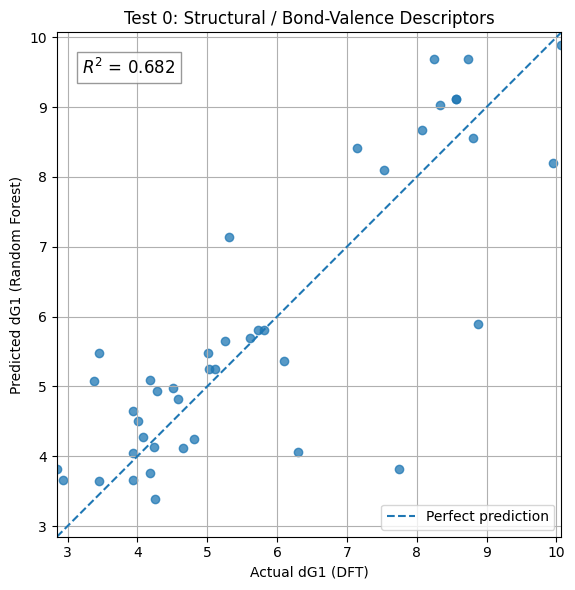


Feature importance:


,Descriptor,Importance
0,Ionicradius,0.795092
1,BV_Oxygen,0.105260
2,instabilityindex,0.099648


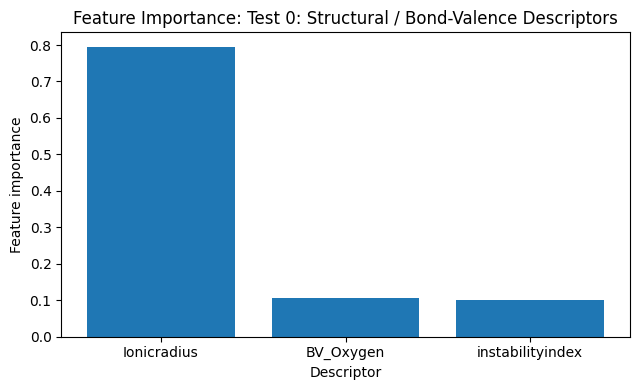

In [ ]:
# Test 0: simple structural / bond-valence descriptor set
structural_features = [
    "Ionicradius",
    "instabilityindex",
    "BV_Oxygen",
]

structural_result = run_descriptor_model(
    structural_features,
    "Test 0: Structural / Bond-Valence Descriptors"
)

## 6. Test 1: Can Electronic Descriptors Do Better?

The structural model captures part of the behavior, but there is substantial room for improvement.

Earlier work on these cathode materials emphasized **metal identity and oxidation state** as useful ways to rationalize metal-release trends. The expanded study therefore asked whether these ideas could be extended across a much more chemically diverse dataset.

We test:

- `Z` — metal identity
- `d_diff` — spin descriptor $S$
- `OS` — oxidation state

> **Hypothesis:** Metal identity, spin, and oxidation state contain enough electronic information to describe metal-release energetics.

Before running the cell, ask yourself: **Which of these three descriptors do you expect to matter most?**

Test 1: Z + Spin + Oxidation State
----------------------------------
Descriptors: Z, d_diff, OS
R² = 0.894
RMSE = 0.665


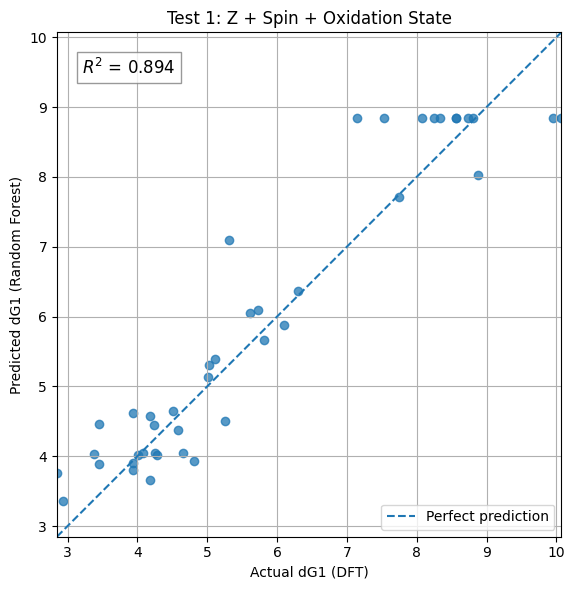


Feature importance:


,Descriptor,Importance
0,Z,0.397715
1,d_diff,0.383683
2,OS,0.218602


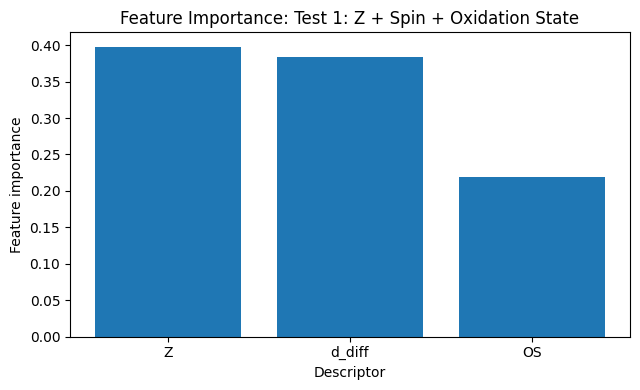

In [ ]:
# Test 1: oxidation-state-based descriptor set
os_features = [
    "Z",       # metal identity
    "d_diff",  # spin descriptor S
    "OS",      # oxidation state
]

os_result = run_descriptor_model(
    os_features,
    "Test 1: Z + Spin + Oxidation State"
)

## 7. What Might Oxidation State Be Missing?

The oxidation-state model performs **very well** in this simplified notebook. That is important: the next step is not about declaring OS "wrong."

Instead, look closely at the **shape of the parity plot**.

In the published analysis, the oxidation-state model showed regions where the Random Forest returned nearly the same predicted energy for structures whose DFT energies varied — visually producing **shelf-like regions** in the parity plot.

That observation raises a more subtle scientific question:

> **Can two metal sites with similar oxidation state still have meaningfully different metal–oxygen bonding?**

Oxidation state compresses a complicated electronic structure into a single number. In compositionally complex oxides, local coordination and covalency may vary even when oxidation state changes only modestly.

The DFT projected density of states gives us another option: directly quantify the overlap between **metal $d$** and **oxygen $p$** states.

## 8. Test 2: Replace Oxidation State with Hybridization

Now we make **one scientifically motivated substitution**:

- Keep **metal identity (`Z`)**
- Keep **spin (`d_diff`)**
- Replace **oxidation state (`OS`)** with **metal–oxygen hybridization (`Hybrid`)**

The `Hybrid` column corresponds to the $H_{d/p}$ concept used in the published study: a descriptor derived from the shared metal-$d$ / oxygen-$p$ electronic structure.

> **New hypothesis:** A descriptor tied directly to metal–oxygen covalent mixing may resolve local bonding differences that oxidation state alone cannot.

The important question is not only whether $R^2$ changes. Also ask:

- Does the parity plot look less structured or less "shelf-like"?
- Does the model better distinguish structures with similar conventional chemical labels?
- Which representation gives us a more physically meaningful explanation?

Test 2: Z + Spin + Hybridization
--------------------------------
Descriptors: Z, d_diff, Hybrid
R² = 0.901
RMSE = 0.641


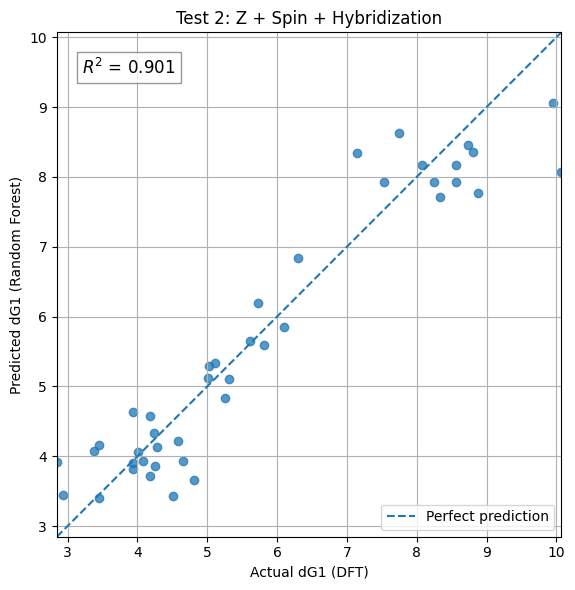


Feature importance:


,Descriptor,Importance
0,Z,0.401623
1,d_diff,0.319839
2,Hybrid,0.278538


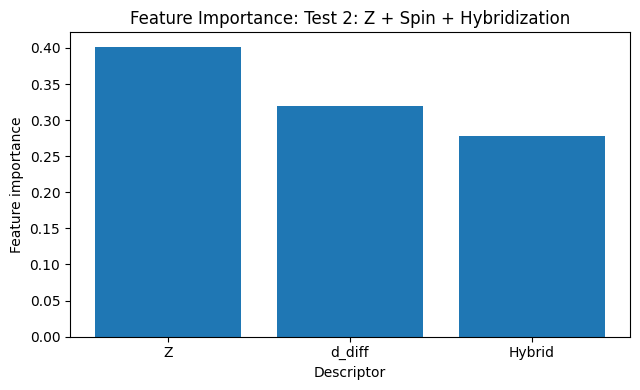

In [ ]:
# Test 2: hybridization-based descriptor set
hybrid_features = [
    "Z",       # metal identity
    "d_diff",  # spin descriptor S
    "Hybrid",  # metal d / oxygen p hybridization (H d/p)
]

hybrid_result = run_descriptor_model(
    hybrid_features,
    "Test 2: Z + Spin + Hybridization"
)

## 9. Compare the Scientific Hypotheses

Now compare all three models.

The largest improvement occurs when we move from a simple structural/bond-valence picture to descriptors that encode **metal identity and electronic structure**.

The OS → hybridization step is more subtle. In this particular teaching split, the global $R^2$ values may be very similar. The scientific value of the hybridization descriptor is that it gives a **more direct connection to local metal–oxygen bonding** and can resolve chemistry that oxidation state compresses away.

> **A better scientific descriptor does not always announce itself through a dramatic jump in one performance metric.**

Model quality includes predictive accuracy, physical interpretability, robustness, and whether systematic errors remain.

In [ ]:
# Compare all three descriptor hypotheses
comparison = pd.DataFrame([
    {
        "Hypothesis": "Structural / bond-valence",
        "Descriptors": "Ionicradius, instabilityindex, BV_Oxygen",
        "R²": structural_result["r2"],
        "RMSE": structural_result["rmse"],
    },
    {
        "Hypothesis": "Z + Spin + OS",
        "Descriptors": "Z, d_diff, OS",
        "R²": os_result["r2"],
        "RMSE": os_result["rmse"],
    },
    {
        "Hypothesis": "Z + Spin + Hybridization",
        "Descriptors": "Z, d_diff, Hybrid",
        "R²": hybrid_result["r2"],
        "RMSE": hybrid_result["rmse"],
    },
])

display(comparison.round(3))

,Hypothesis,Descriptors,R²,RMSE
0,Structural / bond-valence,"Ionicradius, instabilityindex, BV_Oxygen",0.682,1.152
1,Z + Spin + OS,"Z, d_diff, OS",0.894,0.665
2,Z + Spin + Hybridization,"Z, d_diff, Hybrid",0.901,0.641


## 10. What Did We Learn?

The point of this exercise was not simply to maximize $R^2$.

Our models tell a scientific story:

1. **Simple structural and bond-valence descriptors** capture part of the metal-release behavior.
2. Adding **metal identity, spin, and oxidation state** gives much stronger predictive information.
3. Replacing oxidation state with **metal–oxygen hybridization** gives a descriptor more directly tied to the local bonding physics and helps refine how we interpret the model.

This is one way AI/ML can contribute to computational chemistry:

> **Machine learning finds patterns across many calculations. Chemical physics tells us what those patterns mean — and where our descriptions need to improve.**

The published study went much further, including repeated train/test sampling, descriptor-correlation analysis, and detailed examination of individual metal sites and local coordination environments.

# Explore on Your Own

Everything below this point is **optional for the live ACID discussion**.

If you save your own copy of the notebook, this is where you can start experimenting rather than following the published scientific storyline.

## 11. Try Your Own Descriptor Hypothesis

Choose descriptors that represent a scientific idea and see what happens.

Some possibilities:

- Test descriptors **one at a time**. Which carries the most predictive information by itself?
- Combine 2–5 descriptors that you think capture complementary chemistry.
- Try to achieve strong performance **without `Z`**. Can electronic structure replace simple metal identity?
- Compare a chemically interpretable small model with a larger model.

Record both the model performance **and what the result suggests scientifically**.

## Descriptor Reference

Want to test your own hypothesis? Here are the descriptors available in the dataset.

| CSV Label | What It Represents |
|---|---|
| `Z` | Atomic number of the metal being removed |
| `OS` | Oxidation state of the metal |
| `Hybrid` | Metal d / oxygen p orbital hybridization (H d/p) |
| `BV_vac` | Bond valence sum of the MOH group before removal |
| `Charge_vac` | Charge of the MOH group before removal |
| `Mag_vac` | Magnetic moment associated with the MOH group |
| `Mag_env` | Magnetic moment of the surrounding atomic environment |
| `Mag_inst` | Difference between the MOH and surrounding magnetic moments |
| `BV_Oxygen` | Bond valence sum of the oxygen in the removed MOH group |
| `Total_d_electrons` | Total d-electron population of the metal |
| `d_up_tot` | Spin-up d-electron population |
| `d_down_tot` | Spin-down d-electron population |
| `d_diff` | Difference between spin-up and spin-down d-electron populations; used here as the spin descriptor **S** |
| `t2g` | d-electron population in the t2g orbitals |
| `eg` | d-electron population in the eg orbitals |
| `band_center_diff` | Difference between the metal d-band and oxygen p-band centers |
| `instabilityindex` | Global Instability Index (GII), a bond-valence-derived measure of structural strain |
| `Ionicradius` | Ionic radius of the metal |

**Tip:** Don't choose descriptors just because they sound important. Form a chemical hypothesis, test it, and then ask whether the result makes physical sense.

My Descriptor Hypothesis
------------------------
Descriptors: Mag_vac, Mag_env, BV_Oxygen
R² = 0.623
RMSE = 1.254


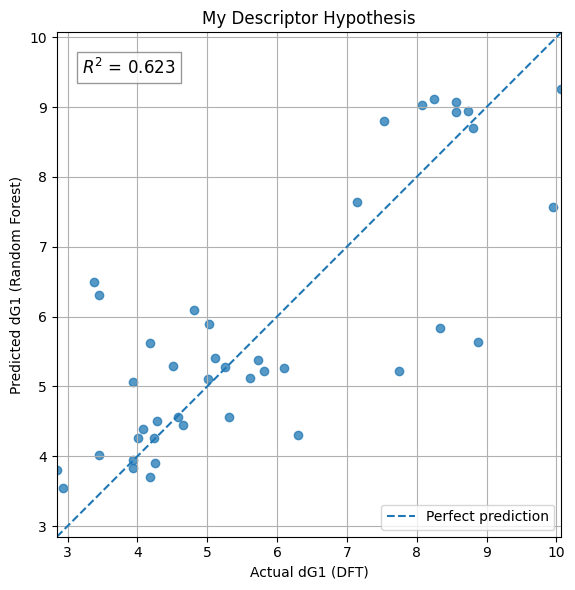


Feature importance:


,Descriptor,Importance
0,Mag_vac,0.661555
1,BV_Oxygen,0.216852
2,Mag_env,0.121593


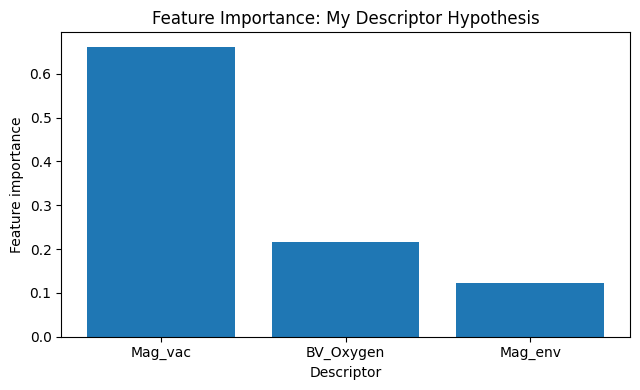

In [ ]:
# ==========================================================
# 🔬 TRY IT YOURSELF
# Edit only the descriptor list below.
# ==========================================================

my_features = [
    "Mag_vac",
    "Mag_env",
    "BV_Oxygen",
]

my_result = run_descriptor_model(
    my_features,
    "My Descriptor Hypothesis"
)

## 12. Bonus: Do Some Descriptors Carry the Same Information?

Descriptor selection is not just about finding individually strong predictors. Some descriptors may encode **similar underlying chemistry**, making them partly redundant.

The correlation heatmap below shows how strongly pairs of descriptors vary together.

Questions to consider:

- Which descriptors are strongly correlated?
- Which descriptors appear to carry different information?
- Why might adding two highly correlated descriptors provide less benefit than adding complementary descriptors?

> **Feature importance asks:** Which descriptors did the model use most?  
> **Correlation asks:** Are different descriptors carrying similar information?

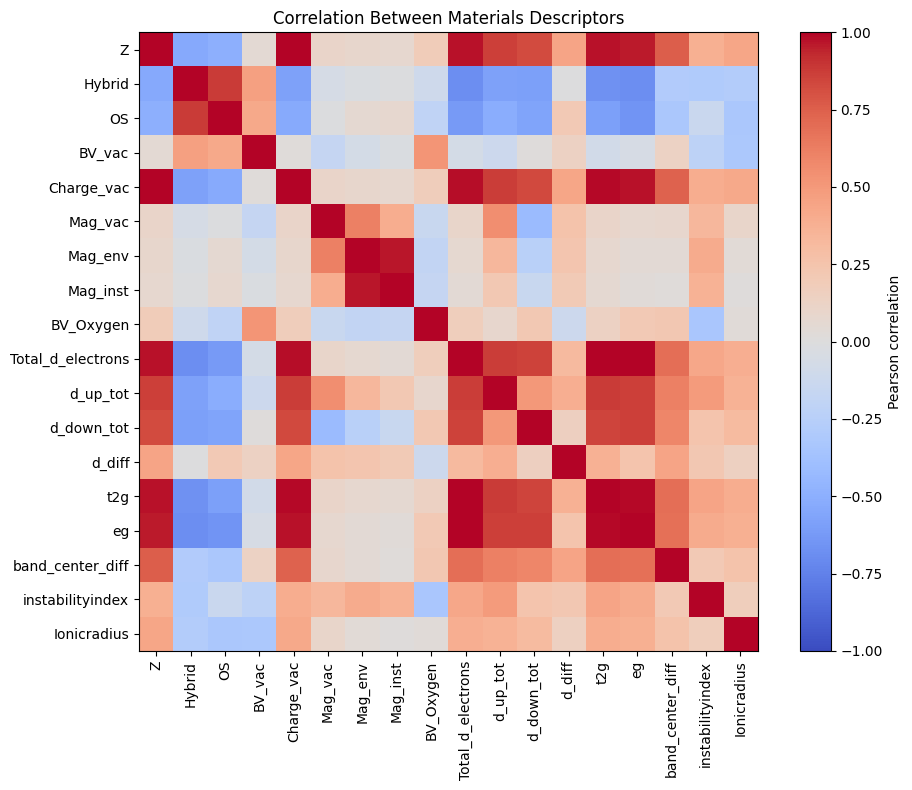

In [ ]:
# Correlation matrix of all descriptors

descriptor_cols = [
    "Z", "Hybrid", "OS", "BV_vac", "Charge_vac",
    "Mag_vac", "Mag_env", "Mag_inst",
    "BV_Oxygen", "Total_d_electrons",
    "d_up_tot", "d_down_tot", "d_diff",
    "t2g", "eg", "band_center_diff",
    "instabilityindex", "Ionicradius"
]

corr = df[descriptor_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(descriptor_cols)), descriptor_cols, rotation=90)
plt.yticks(range(len(descriptor_cols)), descriptor_cols)
plt.colorbar(im, label="Pearson correlation")
plt.title("Correlation Between Materials Descriptors")
plt.tight_layout()
plt.show()

## Descriptor Reference

| CSV label | Physical meaning |
|:--|:--|
| `Z` | Atomic number / identity of the metal being removed |
| `OS` | Oxidation state of the metal |
| `Hybrid` | Metal $d$ / oxygen $p$ hybridization ($H_{d/p}$ concept in the published study) |
| `d_diff` | Difference between spin-up and spin-down $d$ electrons; spin descriptor $S$ |
| `BV_vac` | Bond-valence sum of the MOH group before removal |
| `Charge_vac` | Charge sum of the MOH group before removal |
| `Mag_vac` | Sum of magnetic moments of the MOH group |
| `Mag_env` | Sum of magnetic moments of surrounding atoms |
| `Mag_inst` | Magnetic-moment difference between the site and its environment |
| `BV_Oxygen` | Bond-valence sum associated with the oxygen in the removed group |
| `Total_d_electrons` | Total number of metal $d$ electrons |
| `d_up_tot` | Number of spin-up $d$ electrons |
| `d_down_tot` | Number of spin-down $d$ electrons |
| `t2g` | Number of $d$ electrons in $t_{2g}$ orbitals |
| `eg` | Number of $d$ electrons in $e_g$ orbitals |
| `band_center_diff` | Difference between metal $d$-band and oxygen $p$-band centers |
| `instabilityindex` | Global Instability Index (GII), a bond-valence-derived measure of bond strain / structural instability |
| `Ionicradius` | Ionic radius of the metal for the assigned oxidation state |

### Research connection

This teaching notebook is adapted from the descriptor-discovery workflow in the CFN study by Hudson *et al.*, **J. Phys. Chem. C (2025), 129, 15782–15796**, which examined compositional tuning, local coordination, and metal-release energetics in layered battery cathode materials.